# Unaligned Resampling Visualization

Visualizes resampling results for cases where the resample window does NOT
cover all input entries. Energy is intentionally lost because entries outside
the resample window are excluded.

Loads pre-generated case data from the `cases/` folder.

In [1]:
import os

%matplotlib inline
%load_ext autoreload
%autoreload 2

from ethos_penalps.testing.load_profile.resampling_helpers import (
    list_available_cases,
    load_resampling_test_case,
    plot_compare_energy,
    plot_duration_distribution,
    plot_input_vs_resampled,
    plot_input_vs_resampled_energy,
)

CASES_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "cases")

## Select a Case

In [2]:
available_cases = list_available_cases(CASES_DIR)
print("Available cases:")
for case in available_cases:
    print(f"  - {case}")

CASE_NAME = None
if CASE_NAME is None:
    CASE_NAME = available_cases[0]
print(f"\nSelected case: {CASE_NAME}")

Available cases:
  - both_sides_trimmed
  - end_trimmed
  - mid_entry_trim_varying
  - start_trimmed

Selected case: both_sides_trimmed


## Load Case Data

In [3]:
case_dir = os.path.join(CASES_DIR, CASE_NAME)
meta, resampled_result, parameters = load_resampling_test_case(case_dir)

RESAMPLE_FREQUENCY = parameters["resample_frequency"]

print(f"Input: {len(meta.list_of_load_profiles)} entries, Output: {len(resampled_result.list_of_load_profiles)} bins")
print(f"Entry range:    {parameters['entry_start']} to {parameters['entry_end']}")
print(f"Resample range: {parameters['start']} to {parameters['end']}")
print(f"Resample frequency: {RESAMPLE_FREQUENCY}")
print()
print(f"Input total energy:     {meta.total_energy:.6f} {meta.energy_unit}")
print(f"Resampled total energy: {resampled_result.total_energy:.6f} {resampled_result.energy_unit}")
print(f"Energy lost:            {meta.total_energy - resampled_result.total_energy:.6f} {meta.energy_unit}")

Input: 5 entries, Output: 3 bins
Entry range:    2021-01-01T00:00:00 to 2021-01-01T00:05:00
Resample range: 2021-01-01T00:01:00 to 2021-01-01T00:04:00
Resample frequency: 1min

Input total energy:     150.000000 MJ
Resampled total energy: 90.000000 MJ
Energy lost:            60.000000 MJ


## 1. Input vs. Resampled Power Profile

Note: the input entries extend beyond the resampled range.

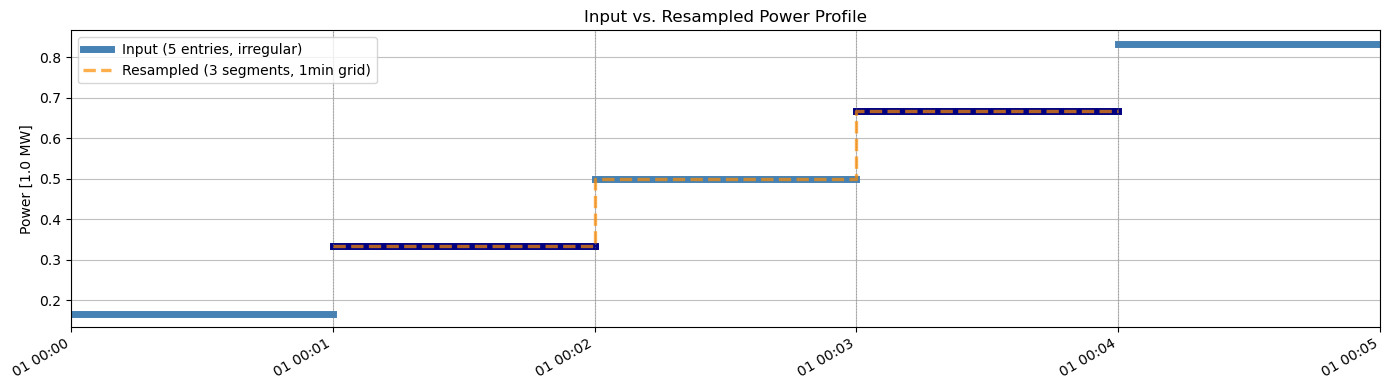

In [4]:
plot_input_vs_resampled(meta, resampled_result)

## 2. Energy Comparison: Input Entries vs. Resampled Bins

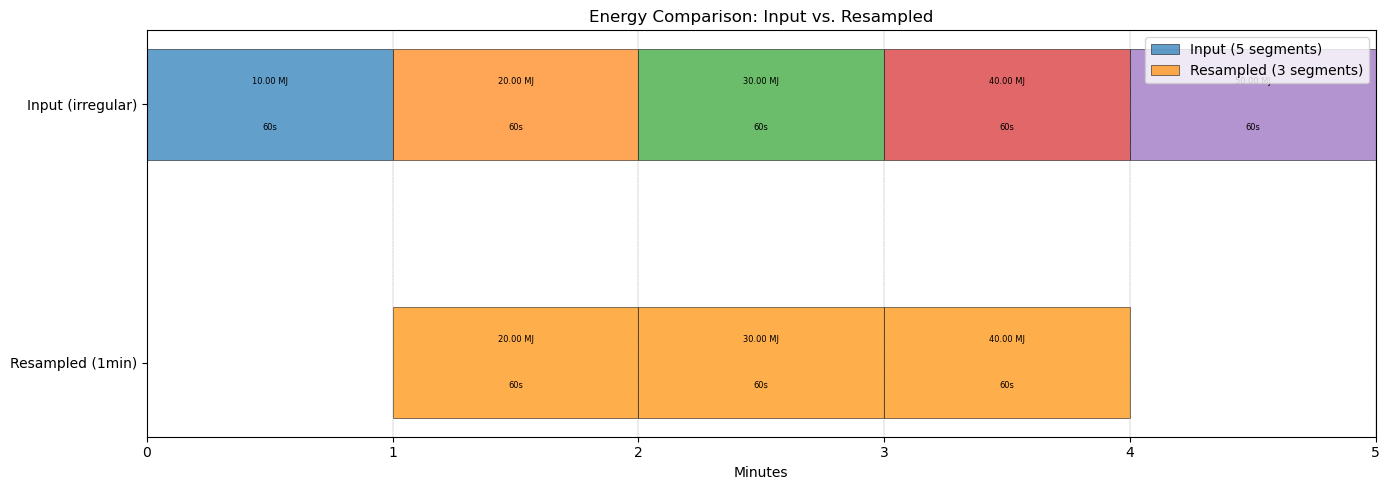

In [5]:
plot_compare_energy(meta, resampled_result)

## 3. Cumulative Energy: Input vs. Resampled

Shows how cumulative energy diverges — the resampled curve plateaus lower
because entries outside the resample window are excluded.

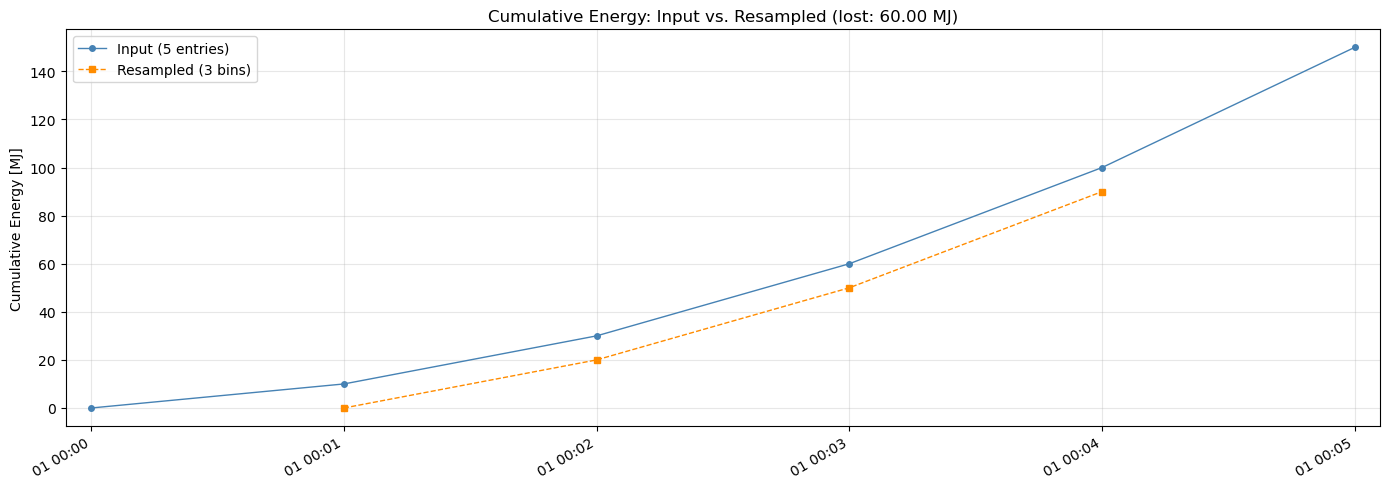

In [6]:
plot_input_vs_resampled_energy(meta, resampled_result)

## 4. Distribution of Input Entry Durations

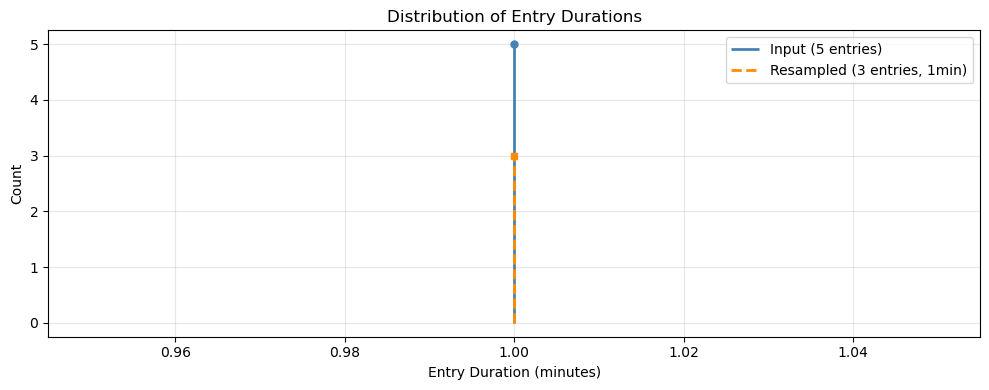

In [7]:
plot_duration_distribution(meta, resampled_result)